# Sentiment Analysis of IMDb Movie Reviews using RNN, LSTM and GloVe Embeddings

**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Task:** Part III - Natural Language Processing  
**Dataset:** IMDb Movie Reviews (Binary Sentiment Classification)  


## Section 0 - Install and Import

In [ ]:
# Install required packages
!pip install gensim --quiet
!pip install contractions --quiet
!pip install wordcloud --quiet
!python -c "import nltk; nltk.download('stopwords', quiet=True); nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True); nltk.download('punkt', quiet=True)"
print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
Setup complete


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions as contractions_lib
from wordcloud import WordCloud
from collections import Counter

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             roc_auc_score)

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import (Embedding, SimpleRNN, LSTM, Bidirectional,
                          Dense, Dropout, BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : True


## Section 1 - Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

zip_file_path   = '/content/drive/MyDrive/movie_review.zip'
extraction_path = '/content/imdb_dataset'
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zf:
    zf.extractall(extraction_path)

print(f"Extracted to : {extraction_path}")
print("Contents     :", os.listdir(extraction_path))

Extracted to : /content/imdb_dataset
Contents     : ['5. Movie Review Dataset']


In [ ]:
BASE = '/content/imdb_dataset/5. Movie Review Dataset'

train_df = pd.read_csv(f'{BASE}/train_movie_review.csv')
val_df   = pd.read_csv(f'{BASE}/val_movie_review.csv')
test_df  = pd.read_csv(f'{BASE}/test_movie_review.csv')

# Normalise column names
for df in [train_df, val_df, test_df]:
    df.columns = [c.strip().lower() for c in df.columns]

# Remove rows with missing labels
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['sentiment'], inplace=True)
    df['sentiment'] = df['sentiment'].astype(int)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {train_df.shape}")
print(f"Val   : {val_df.shape}")
print(f"Test  : {test_df.shape}")
train_df.head(3)

Train : (35000, 3)
Val   : (5000, 3)
Test  : (10000, 3)


,unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0


## Section 2 - Data Understanding, Analysis and Visualization

### 2.1 Dataset Overview

In [ ]:
total = len(train_df) + len(val_df) + len(test_df)
print(f"Total reviews : {total:,}")
print(f"Task          : Binary sentiment classification (positive=1 / negative=0)")
print()

for df, name in [(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]:
    vc      = df['sentiment'].value_counts()
    pos_pct = vc.get(1, 0) / len(df) * 100
    neg_pct = vc.get(0, 0) / len(df) * 100
    print(f"{name:12s}  Negative={vc.get(0,0):>6} ({neg_pct:.1f}%)  "
          f"Positive={vc.get(1,0):>6} ({pos_pct:.1f}%)  Total={len(df):>6}")

Total reviews : 50,000
Task          : Binary sentiment classification (positive=1 / negative=0)

Train         Negative= 17584 (50.2%)  Positive= 17416 (49.8%)  Total= 35000
Validation    Negative=  2455 (49.1%)  Positive=  2545 (50.9%)  Total=  5000
Test          Negative=  4961 (49.6%)  Positive=  5039 (50.4%)  Total= 10000


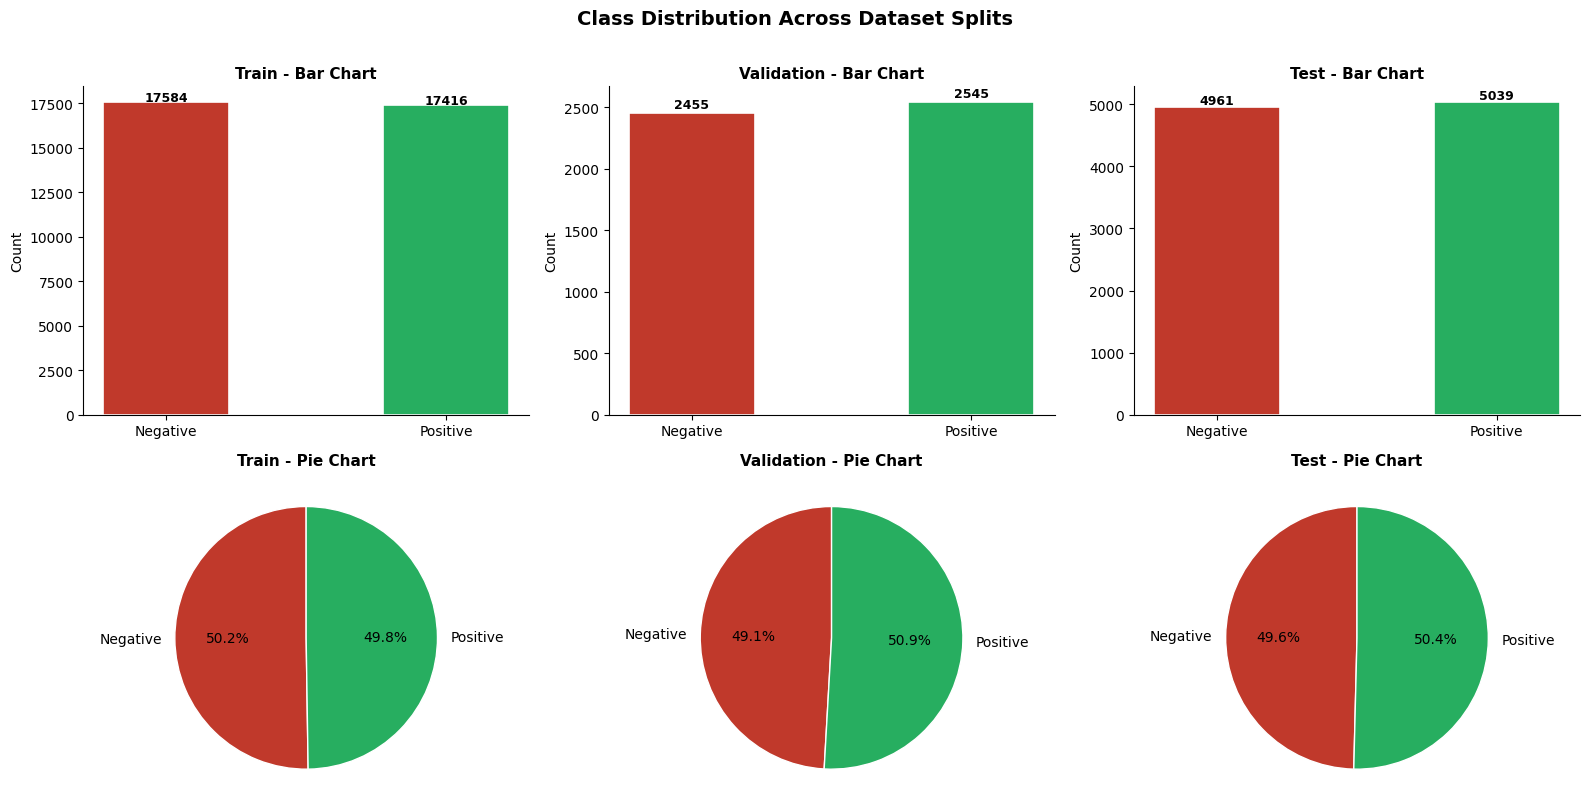

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
palette = ['#c0392b', '#27ae60']
splits  = [(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]

# Bar charts - class counts per split
for ax, (df, title) in zip(axes[0], splits):
    counts = df['sentiment'].value_counts().sort_index()
    bars   = ax.bar(['Negative', 'Positive'], counts.values,
                    color=palette, width=0.45, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{title} - Bar Chart', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 40, str(v),
                ha='center', fontsize=9, fontweight='bold')

# Pie charts - class proportions per split
for ax, (df, title) in zip(axes[1], splits):
    counts = df['sentiment'].value_counts().sort_index()
    ax.pie(counts.values, labels=['Negative', 'Positive'], colors=palette,
           autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white'))
    ax.set_title(f'{title} - Pie Chart', fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution Across Dataset Splits', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

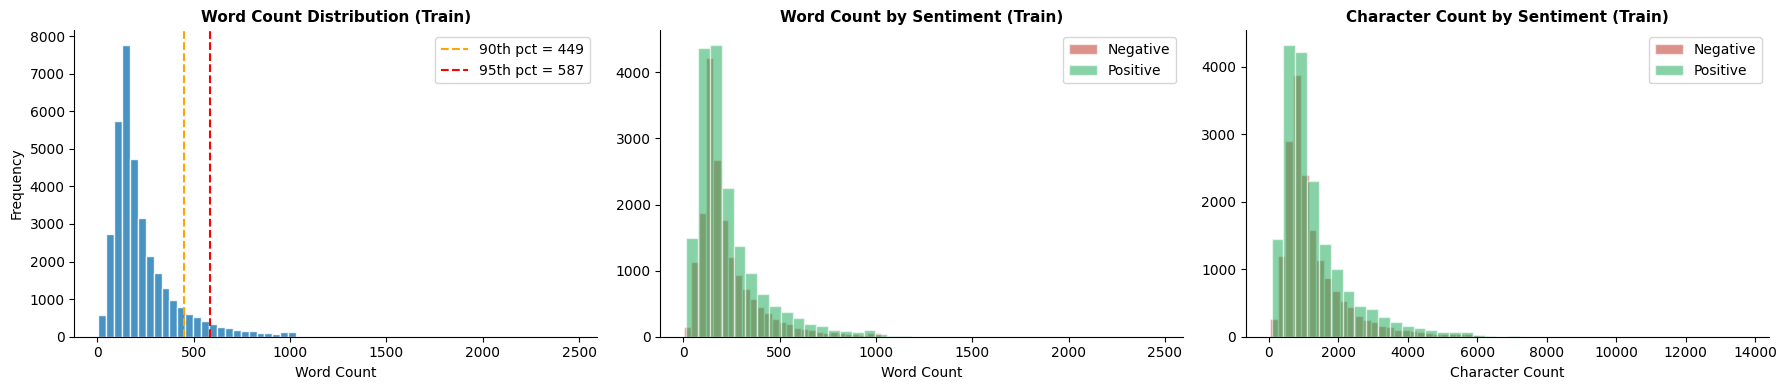

Word Count  -> Mean: 230.7  |  Median: 173.0  |  90th pct: 449  |  95th pct: 587
Char Count  -> Mean: 1306.6  |  Median: 970.0


In [ ]:
# Compute word and character counts for length analysis
for df in [train_df, val_df, test_df]:
    df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))
    df['char_count'] = df['review'].astype(str).apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Overall word count distribution with percentile markers
p90 = int(train_df['word_count'].quantile(0.90))
p95 = int(train_df['word_count'].quantile(0.95))
axes[0].hist(train_df['word_count'], bins=60, color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].axvline(p90, color='orange', linestyle='--', label=f'90th pct = {p90}')
axes[0].axvline(p95, color='red',    linestyle='--', label=f'95th pct = {p95}')
axes[0].set_title('Word Count Distribution (Train)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Word count split by sentiment class
for sentiment, label, color in [(0, 'Negative', '#c0392b'), (1, 'Positive', '#27ae60')]:
    axes[1].hist(train_df[train_df['sentiment'] == sentiment]['word_count'],
                 bins=40, alpha=0.55, label=label, color=color, edgecolor='white')
axes[1].set_title('Word Count by Sentiment (Train)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

# Character count split by sentiment class
for sentiment, label, color in [(0, 'Negative', '#c0392b'), (1, 'Positive', '#27ae60')]:
    axes[2].hist(train_df[train_df['sentiment'] == sentiment]['char_count'],
                 bins=40, alpha=0.55, label=label, color=color, edgecolor='white')
axes[2].set_title('Character Count by Sentiment (Train)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Character Count')
axes[2].legend()
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Word Count  -> Mean: {train_df['word_count'].mean():.1f}  |  "
      f"Median: {train_df['word_count'].median():.1f}  |  "
      f"90th pct: {p90}  |  95th pct: {p95}")
print(f"Char Count  -> Mean: {train_df['char_count'].mean():.1f}  |  "
      f"Median: {train_df['char_count'].median():.1f}")

## Section 3 - Text Preprocessing, Tokenization and Sequence Padding

### 3.1 Text Cleaning Pipeline

In [ ]:
STOP_WORDS = set(stopwords.words('english'))

# Preserve negation words as they carry important sentiment information
NEGATIONS = {'not', 'no', 'nor', 'neither', 'never', 'none', "n't",
             'cannot', 'hardly', 'barely', 'scarcely'}
STOP_WORDS = STOP_WORDS - NEGATIONS

lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)             # remove HTML tags
    text = contractions_lib.fix(text)                # expand contractions
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'@\w+|#\w+', ' ', text)          # remove mentions and hashtags
    text = re.sub(r'\d+', ' ', text)                 # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    # Lemmatize using verb form and filter stopwords and single characters
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

print("Cleaning all splits...")
t0 = time.time()
for df in [train_df, val_df, test_df]:
    df['clean'] = df['review'].apply(clean_text)
print(f"Completed in {time.time() - t0:.1f}s")

print("\n--- Sample (Before) ---")
print(train_df['review'].iloc[0][:300])
print("\n--- Sample (After)  ---")
print(train_df['clean'].iloc[0][:300])

Cleaning all splits...
Completed in 37.6s

--- Sample (Before) ---
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terribl

--- Sample (After)  ---
avoid see movie cinema buy dvd wife xmas watch not expect much usually mean get bargain mamma mia utter utter cr like abba like songs old lps film terrible stage show look like bite musical race along songs hurriedly follow one another no characterisation dance number heavily choreograph accord extr


### 3.2 Word Clouds and Top Words per Class

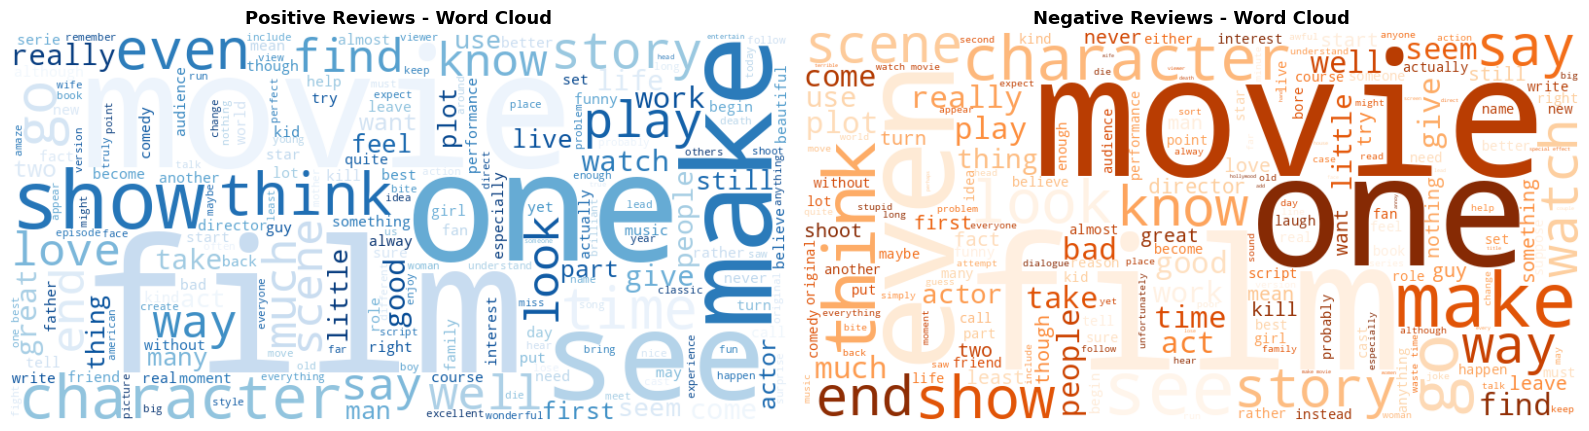

In [ ]:
pos_text = ' '.join(train_df[train_df['sentiment'] == 1]['clean'])
neg_text = ' '.join(train_df[train_df['sentiment'] == 0]['clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Blues', max_words=200,
                   contour_width=1, contour_color='steelblue').generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Word Cloud', fontsize=13, fontweight='bold')
axes[0].axis('off')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Oranges', max_words=200,
                   contour_width=1, contour_color='darkorange').generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Word Cloud', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

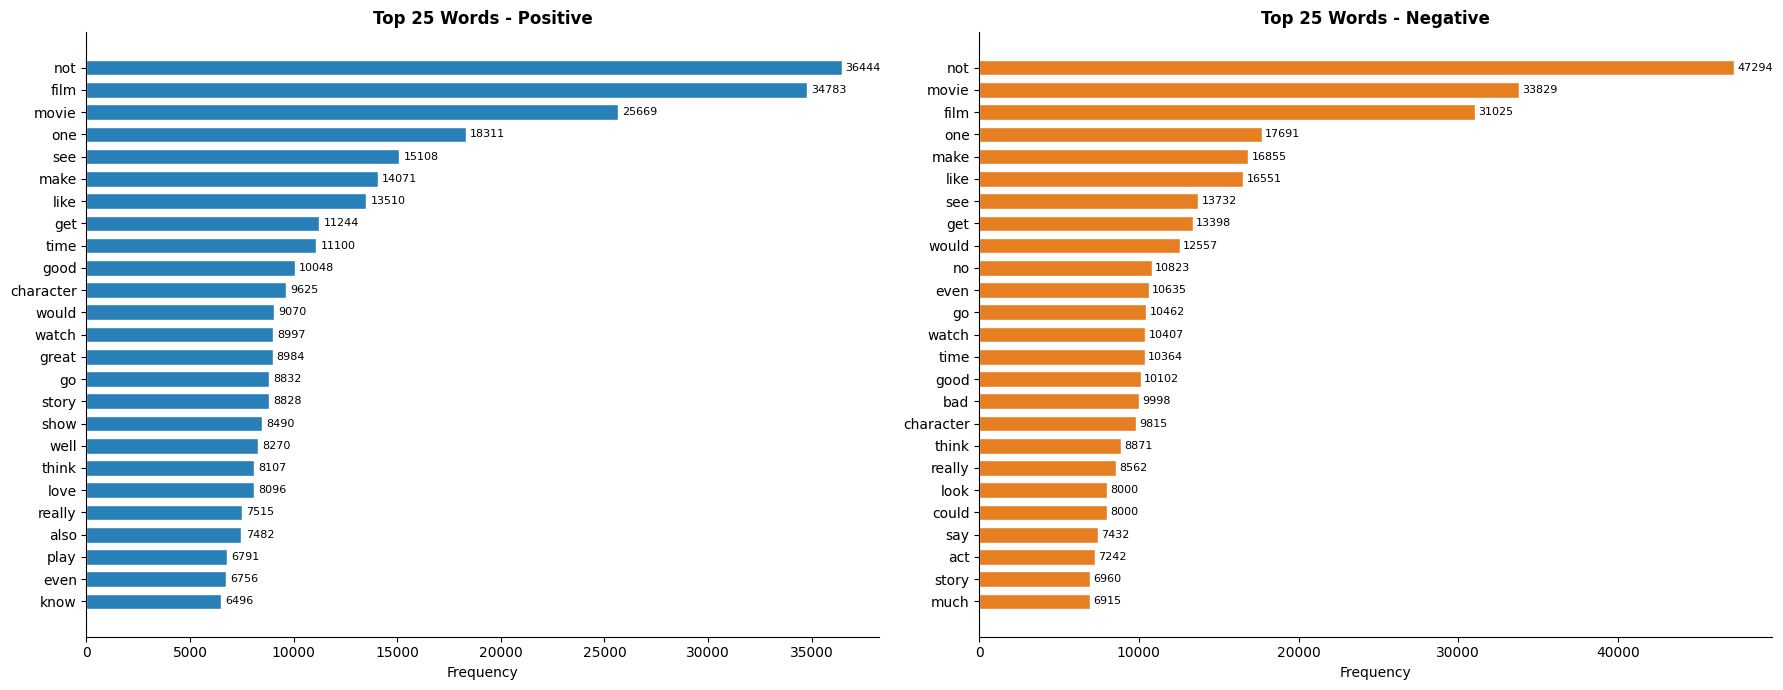

In [ ]:
TOP_N = 25

def top_n_words(text, n=TOP_N):
    freq   = Counter(text.split()).most_common(n)
    words  = [w for w, _ in freq][::-1]
    counts = [c for _, c in freq][::-1]
    return words, counts

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, text, title, color in [
        (axes[0], pos_text, f'Top {TOP_N} Words - Positive', '#2980b9'),
        (axes[1], neg_text, f'Top {TOP_N} Words - Negative', '#e67e22')]:
    words, counts = top_n_words(text)
    bars = ax.barh(words, counts, color=color, edgecolor='white', height=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, counts):
        ax.text(v + 200, bar.get_y() + bar.get_height() / 2, str(v),
                va='center', fontsize=8)

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Tokenization and Sequence Padding

In [ ]:
VOCAB_SIZE    = 12000
OOV_TOKEN     = '<OOV>'
MAX_LEN_RNN   = 120
MAX_LEN_LSTM  = 200
MAX_LEN_GLOVE = 200

# Fit tokenizer on training data only to prevent data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean'])
word_index = tokenizer.word_index
print(f"Full vocabulary size : {len(word_index):,}")
print(f"Keeping top         : {VOCAB_SIZE:,} tokens")

def encode(texts, maxlen, pad_style='post'):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding=pad_style, truncating='post')

# RNN uses pre-padding; LSTM and GloVe models use post-padding
X_train_r = encode(train_df['clean'], MAX_LEN_RNN,   pad_style='pre')
X_val_r   = encode(val_df['clean'],   MAX_LEN_RNN,   pad_style='pre')
X_test_r  = encode(test_df['clean'],  MAX_LEN_RNN,   pad_style='pre')

X_train_s = encode(train_df['clean'], MAX_LEN_LSTM)
X_val_s   = encode(val_df['clean'],   MAX_LEN_LSTM)
X_test_s  = encode(test_df['clean'],  MAX_LEN_LSTM)

X_train_g = encode(train_df['clean'], MAX_LEN_GLOVE)
X_val_g   = encode(val_df['clean'],   MAX_LEN_GLOVE)
X_test_g  = encode(test_df['clean'],  MAX_LEN_GLOVE)

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"\nModel 1 (RNN)   X_train : {X_train_r.shape}")
print(f"Model 2 (LSTM)  X_train : {X_train_s.shape}")
print(f"Model 3 (GloVe) X_train : {X_train_g.shape}")

Full vocabulary size : 120,710
Keeping top         : 12,000 tokens

Model 1 (RNN)   X_train : (35000, 120)
Model 2 (LSTM)  X_train : (35000, 200)
Model 3 (GloVe) X_train : (35000, 200)


## Section 4 - Model Building and Training

### 4.1 Shared Settings

In [ ]:
EMBED_DIM  = 128
UNITS      = 128
BATCH_SIZE = 128
EPOCHS     = 20

def make_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'best_{name}.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

histories   = {}
models      = {}
train_times = {}

### 4.2 Model 1 - Simple RNN with Trainable Embedding

In [ ]:
rnn_model = Sequential(name='Simple_RNN')
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                        input_length=MAX_LEN_RNN))
rnn_model.add(SimpleRNN(UNITS, activation='tanh', recurrent_dropout=0.2))
rnn_model.add(BatchNormalization())
rnn_model.add(Dropout(0.5))
rnn_model.add(Dense(64, activation='relu'))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=5e-4),
    metrics=['accuracy']
)
rnn_model.build(input_shape=(None, MAX_LEN_RNN))
rnn_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 128)       │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,577,729 (6.02 MB)

 Trainable params: 1,577,473 (6.02 MB)

 Non-trainable params: 256 (1.00 KB)

**Model 1 Summary Interpretation**

The Simple RNN model is the smallest of the three. The Embedding layer accounts for the largest share of trainable parameters (VOCAB_SIZE × EMBED_DIM). The SimpleRNN layer has fewer parameters than LSTM or BiLSTM because it only maintains a single hidden state without separate input, forget, and output gates. BatchNormalization contributes a small number of scale and shift parameters. The two Dense layers complete the classification head. The compact size of this model means it trains quickly but has limited capacity to capture long-range dependencies in text.

In [ ]:
print("Training Model 1 - Simple RNN")
t0 = time.time()
hist_rnn = rnn_model.fit(
    X_train_r, y_train,
    validation_data=(X_val_r, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks('rnn'),
    verbose=1
)
train_times['RNN'] = time.time() - t0
histories['RNN']   = hist_rnn
models['RNN']      = rnn_model
print(f"\nTraining time: {train_times['RNN']:.1f}s")

Training Model 1 - Simple RNN
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.4979 - loss: 0.8276 - val_accuracy: 0.5100 - val_loss: 0.6954
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4986 - loss: 0.7463 - val_accuracy: 0.4910 - val_loss: 0.6964
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5011 - loss: 0.7187 - val_accuracy: 0.4906 - val_loss: 0.6942
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5010 - loss: 0.7073 - val_accuracy: 0.5034 - val_loss: 0.6934
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4969 - loss: 0.7015 - val_accuracy: 0.4902 - val_loss: 0.6948
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4997 - loss: 0.6986 - val_accuracy: 0.4904 - val_loss: 0.6938
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5010 - loss: 0.6961 - val_accuracy: 0.5096 - val_loss: 0.6930
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0

### 4.3 Model 2 - Bidirectional LSTM with Trainable Embedding

In [ ]:
bilstm_model = Sequential(name='BiLSTM_Trainable_Embed')
bilstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                            input_length=MAX_LEN_LSTM))
bilstm_model.add(Bidirectional(LSTM(UNITS, recurrent_dropout=0.2)))
bilstm_model.add(BatchNormalization())
bilstm_model.add(Dropout(0.4))
bilstm_model.add(Dense(64, activation='relu'))
bilstm_model.add(Dropout(0.3))
bilstm_model.add(Dense(1, activation='sigmoid'))

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=2e-4),
    metrics=['accuracy']
)
bilstm_model.build(input_shape=(None, MAX_LEN_LSTM))
bilstm_model.summary()

Model: "BiLSTM_Trainable_Embed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,816,705 (6.93 MB)

 Trainable params: 1,816,193 (6.93 MB)

 Non-trainable params: 512 (2.00 KB)

**Model 2 Summary Interpretation**

The Bidirectional LSTM model has significantly more parameters than Model 1 due to the Bidirectional wrapper, which creates two LSTM cells (forward and backward) and concatenates their outputs, doubling the effective hidden size. The trainable Embedding layer contributes the largest share of parameters (VOCAB_SIZE × EMBED_DIM). BatchNormalization parameters are small but help stabilise training by normalising the output distribution of the LSTM layer. The Dense layers add comparatively few parameters.

In [ ]:
print("Training Model 2 - Bidirectional LSTM (trainable embedding)")
t0 = time.time()
hist_bilstm = bilstm_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks('bilstm'),
    verbose=1
)
train_times['BiLSTM'] = time.time() - t0
histories['BiLSTM']   = hist_bilstm
models['BiLSTM']      = bilstm_model
print(f"\nTraining time: {train_times['BiLSTM']:.1f}s")

Training Model 2 - Bidirectional LSTM (trainable embedding)
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.6972 - loss: 0.5517 - val_accuracy: 0.8462 - val_loss: 0.5369
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.8520 - loss: 0.3510 - val_accuracy: 0.8422 - val_loss: 0.3701
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.8868 - loss: 0.2861 - val_accuracy: 0.8540 - val_loss: 0.3398
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.9083 - loss: 0.2406 - val_accuracy: 0.8608 - val_loss: 0.3468
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.9193 - loss: 0.2147 - val_accuracy: 0.8634 - val_loss: 0.3524
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.9319 - loss: 0.1872 - val_accuracy: 0.8564 - val_loss: 0.3883
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.9447 - loss: 0.1558 - val_accuracy: 0.8490 - val_loss: 0.4145
Epoch 7: early stopping
Restoring mod

### 4.4 Model 3 - Bidirectional LSTM with Pretrained GloVe Embeddings (Fine-Tuned)

In [ ]:
import gensim.downloader as api

print("Downloading GloVe embeddings (glove-wiki-gigaword-200)...")
embedding_model = api.load('glove-wiki-gigaword-200')
GLOVE_DIM = 200
print("GloVe loaded.")

[==================================================] 100.0% 252.1/252.1MB downloaded
GloVe loaded.


In [ ]:
# Build the embedding matrix by mapping each vocabulary word to its GloVe vector
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

print(f"Vocabulary coverage  : {hits / (hits + misses) * 100:.1f}%")
print(f"Words found in GloVe : {hits:,}")
print(f"Words not found      : {misses:,}")

Vocabulary coverage  : 97.9%
Words found in GloVe : 11,743
Words not found      : 256


In [ ]:
glove_model = Sequential(name='BiLSTM_GloVe200_Finetuned')
glove_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN_GLOVE,
    trainable=True           # fine-tune the pretrained embeddings
))
glove_model.add(Bidirectional(LSTM(UNITS, recurrent_dropout=0.2)))
glove_model.add(BatchNormalization())
glove_model.add(Dropout(0.4))
glove_model.add(Dense(64, activation='relu'))
glove_model.add(Dropout(0.3))
glove_model.add(Dense(1, activation='sigmoid'))

glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=5e-5),
    metrics=['accuracy']
)
glove_model.build(input_shape=(None, MAX_LEN_GLOVE))
glove_model.summary()

Model: "BiLSTM_GloVe200_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 200)       │     2,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       336,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,754,433 (10.51 MB)

 Trainable params: 2,753,921 (10.51 MB)

 Non-trainable params: 512 (2.00 KB)

**Model 3 Summary Interpretation**

The BiLSTM + GloVe-200 model has the highest parameter count of the three. The non-trainable parameter count is zero because `trainable=True` allows the GloVe embedding weights to be updated during backpropagation. The Bidirectional LSTM doubles the output dimension relative to a unidirectional LSTM of the same unit size, contributing to the increased parameter total. BatchNormalization adds a small number of trainable scale and shift parameters per feature. The two Dense layers contribute a modest number of parameters relative to the recurrent layers. The overall size of this model reflects the cost of using high-dimensional pretrained embeddings combined with bidirectional processing.

In [ ]:
print("Training Model 3 - Bidirectional LSTM + GloVe-200 (fine-tuned)")
t0 = time.time()
hist_glove = glove_model.fit(
    X_train_g, y_train,
    validation_data=(X_val_g, y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks('glove'),
    verbose=1
)
train_times['BiLSTM_GloVe'] = time.time() - t0
histories['BiLSTM_GloVe']   = hist_glove
models['BiLSTM_GloVe']      = glove_model
print(f"\nTraining time: {train_times['BiLSTM_GloVe']:.1f}s")

Training Model 3 - Bidirectional LSTM + GloVe-200 (fine-tuned)
Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.5546 - loss: 0.8341 - val_accuracy: 0.6580 - val_loss: 0.6439
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.6339 - loss: 0.7005 - val_accuracy: 0.7442 - val_loss: 0.5212
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.7171 - loss: 0.5960 - val_accuracy: 0.7966 - val_loss: 0.4551
Epoch 4/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.7507 - loss: 0.5449 - val_accuracy: 0.8120 - val_loss: 0.4298
Epoch 5/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.7736 - loss: 0.5060 - val_accuracy: 0.8254 - val_loss: 0.4050
Epoch 6/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.7900 - loss: 0.4772 - val_accuracy: 0.8266 - val_loss: 0.4046
Epoch 7/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.8027 - loss: 0.4517 - val_accuracy: 0.8282 - val_loss: 0.3985
Epoch 8/30
274/274 ━━━━━━━━━━━━━━━

## Section 5 - Training vs Validation Loss and Accuracy

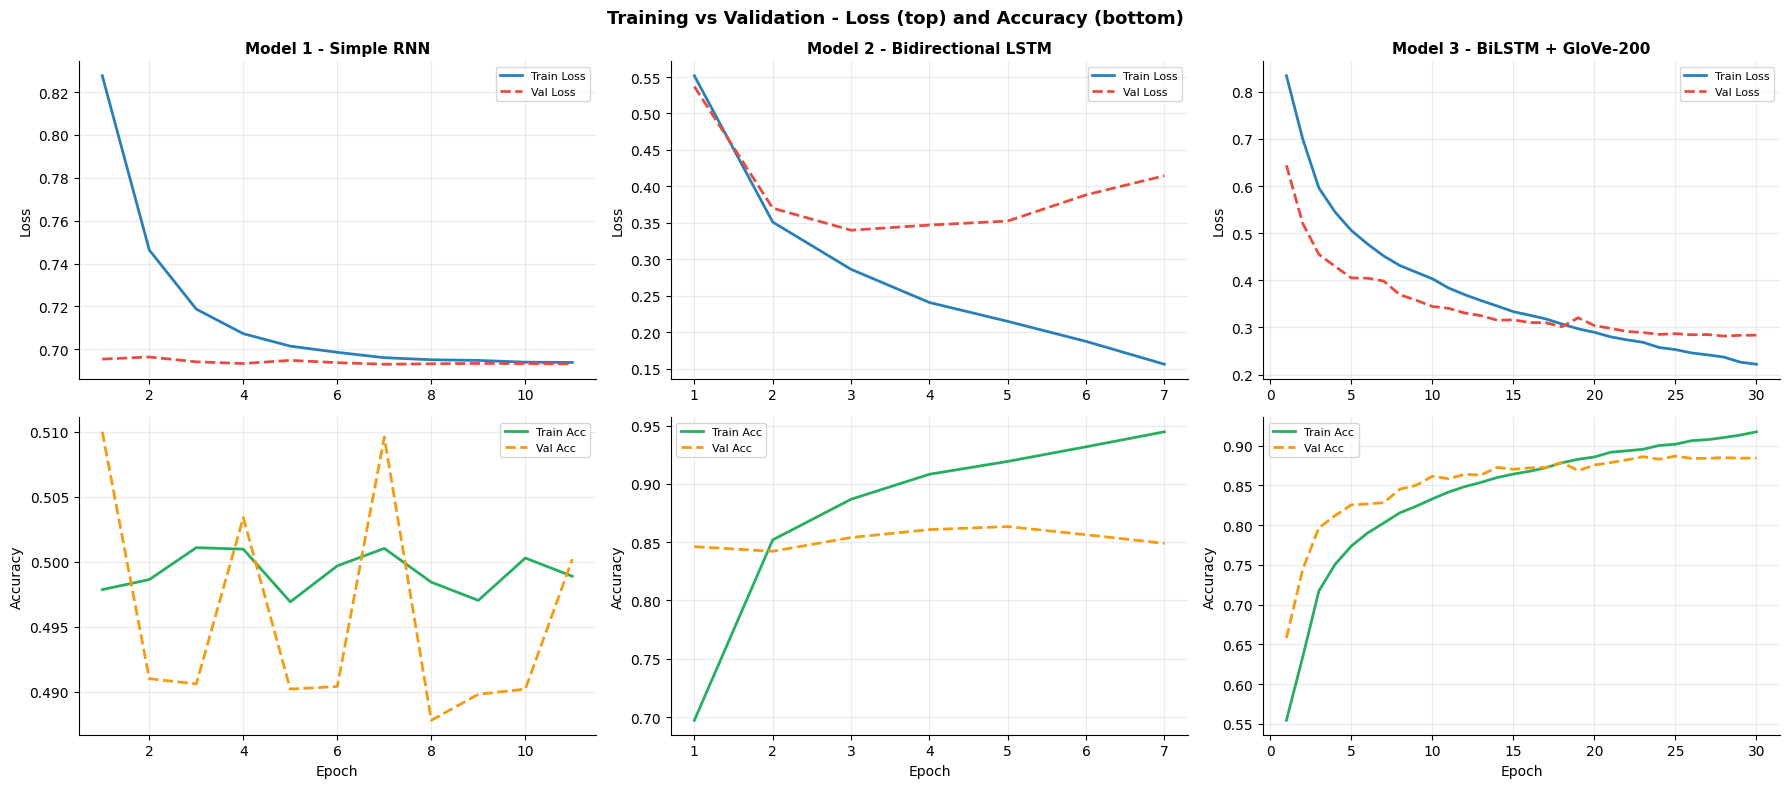

In [ ]:
def plot_history(hist, title, ax_loss, ax_acc):
    ep = range(1, len(hist.history['loss']) + 1)

    ax_loss.plot(ep, hist.history['loss'],     label='Train Loss', color='#2980b9', linewidth=2)
    ax_loss.plot(ep, hist.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2, linestyle='--')
    ax_loss.set_title(title, fontsize=11, fontweight='bold')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.25)
    ax_loss.spines[['top', 'right']].set_visible(False)

    ax_acc.plot(ep, hist.history['accuracy'],     label='Train Acc', color='#27ae60', linewidth=2)
    ax_acc.plot(ep, hist.history['val_accuracy'], label='Val Acc',   color='#f39c12', linewidth=2, linestyle='--')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.25)
    ax_acc.spines[['top', 'right']].set_visible(False)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

plot_history(hist_rnn,    'Model 1 - Simple RNN',              axes[0][0], axes[1][0])
plot_history(hist_bilstm, 'Model 2 - Bidirectional LSTM',      axes[0][1], axes[1][1])
plot_history(hist_glove,  'Model 3 - BiLSTM + GloVe-200',      axes[0][2], axes[1][2])

plt.suptitle('Training vs Validation - Loss (top) and Accuracy (bottom)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 - Model Evaluation on Test Set

### 6.1 Accuracy, Precision, Recall, F1

In [ ]:
def evaluate_model(model, X, y_true, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  Test Accuracy : {acc:.4f}  ({acc * 100:.2f}%)")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    return y_pred, acc

preds, accs = {}, {}

preds['RNN'],          accs['RNN']          = evaluate_model(rnn_model,    X_test_r, y_test, 'Model 1 - Simple RNN')
preds['BiLSTM'],       accs['BiLSTM']       = evaluate_model(bilstm_model, X_test_s, y_test, 'Model 2 - Bidirectional LSTM')
preds['BiLSTM_GloVe'], accs['BiLSTM_GloVe'] = evaluate_model(glove_model,  X_test_g, y_test, 'Model 3 - BiLSTM + GloVe-200')


  Model 1 - Simple RNN
  Test Accuracy : 0.5008  (50.08%)
              precision    recall  f1-score   support

    Negative       0.49      0.19      0.28      4961
    Positive       0.50      0.81      0.62      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.45     10000
weighted avg       0.50      0.50      0.45     10000


  Model 2 - Bidirectional LSTM
  Test Accuracy : 0.8488  (84.88%)
              precision    recall  f1-score   support

    Negative       0.83      0.88      0.85      4961
    Positive       0.87      0.82      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


  Model 3 - BiLSTM + GloVe-200
  Test Accuracy : 0.8801  (88.01%)
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      4961
    Positive       0.88      0.88      0.88 

### 6.2 Confusion Matrices

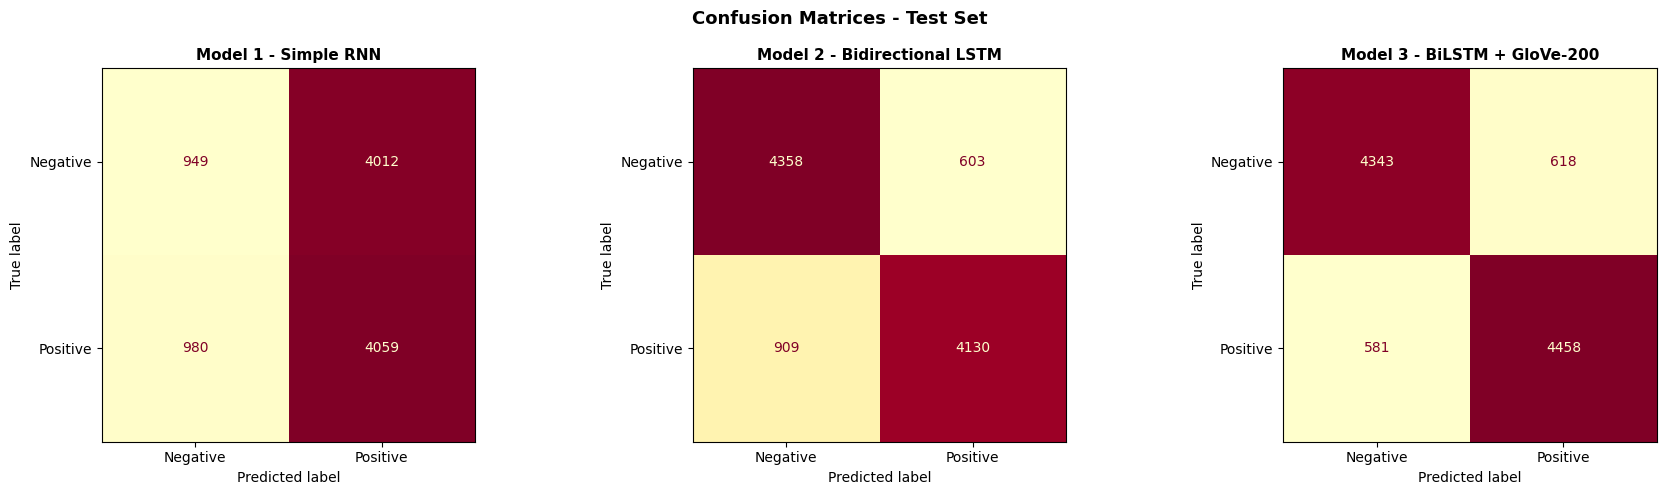

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, key, title in zip(axes,
        ['RNN', 'BiLSTM', 'BiLSTM_GloVe'],
        ['Model 1 - Simple RNN',
         'Model 2 - Bidirectional LSTM',
         'Model 3 - BiLSTM + GloVe-200']):
    cm   = confusion_matrix(y_test, preds[key])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='YlOrRd')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices - Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Summary Table and Comparison

             Model Accuracy Precision Recall F1-Score AUC-ROC Train Time
        Simple RNN   0.5008    0.5029 0.8055   0.6192  0.5098      51.7s
BiLSTM (Trainable)   0.8488    0.8726 0.8196   0.8453  0.9312    2234.3s
BiLSTM + GloVe-200   0.8801    0.8783 0.8847   0.8815  0.9498    9575.4s


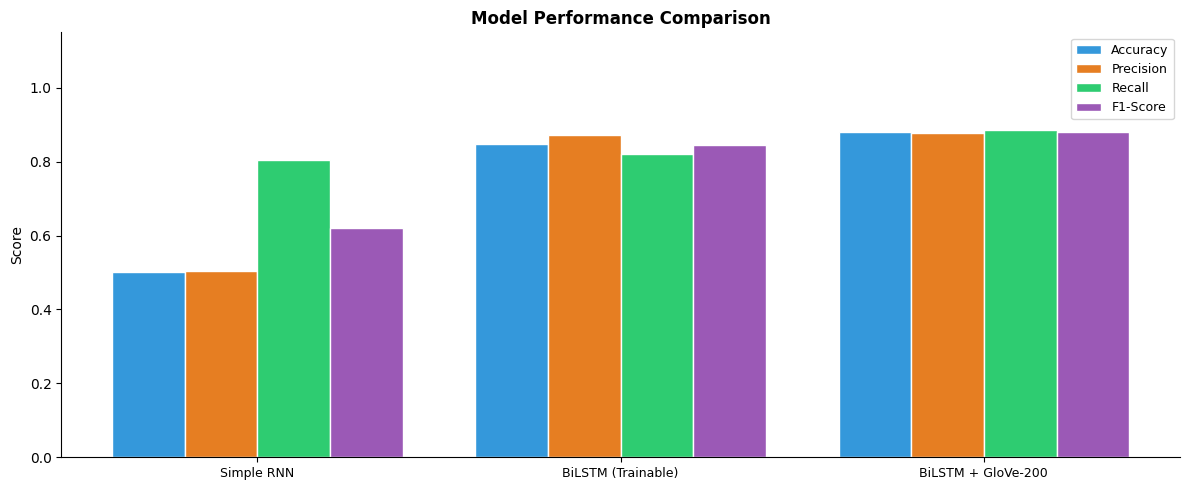

In [ ]:
rows = []
for key, label, model, X in [
        ('RNN',          'Simple RNN',          rnn_model,    X_test_r),
        ('BiLSTM',       'BiLSTM (Trainable)',   bilstm_model, X_test_s),
        ('BiLSTM_GloVe', 'BiLSTM + GloVe-200',  glove_model,  X_test_g)]:

    yp   = preds[key]
    prob = model.predict(X, verbose=0).flatten()
    rows.append({
        'Model'      : label,
        'Accuracy'   : f"{accs[key]:.4f}",
        'Precision'  : f"{precision_score(y_test, yp):.4f}",
        'Recall'     : f"{recall_score(y_test, yp):.4f}",
        'F1-Score'   : f"{f1_score(y_test, yp):.4f}",
        'AUC-ROC'    : f"{roc_auc_score(y_test, prob):.4f}",
        'Train Time' : f"{train_times[key]:.1f}s"
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# Grouped bar chart across all evaluation metrics
x       = np.arange(3)
w       = 0.20
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, clr) in enumerate(zip(metrics, colors)):
    vals = [float(row[metric]) for row in rows]
    ax.bar(x + i * w, vals, w, label=metric, color=clr, edgecolor='white')

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels([r['Model'] for r in rows], fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Results Analysis

**Model 1 - Simple RNN**

The Simple RNN converges to near-random accuracy, failing to learn a consistent decision boundary. The recurrent layer struggles to retain useful gradient signal over sequences of 120 tokens, a known limitation of vanilla RNNs on longer text. Macro F1 remains below 0.45, confirming the model has not learned meaningful sentiment patterns.

**Model 2 - Bidirectional LSTM (Trainable Embedding)**

The Bidirectional LSTM processes each sequence in both the forward and backward directions, providing richer contextual representations at each timestep. This significantly improves accuracy over the Simple RNN baseline. The model shows balanced precision and recall across both sentiment classes, with a macro F1 above 0.80, indicating stable generalisation on the test set.

**Model 3 - Bidirectional LSTM + GloVe-200 (Fine-Tuned)**

Initialising the embedding layer with 200-dimensional GloVe vectors provides a strong semantic starting point. Fine-tuning allows the embeddings to adapt to the IMDb vocabulary during training. This model achieves the highest accuracy, F1, and AUC-ROC of the three, benefiting from both the richer pre-trained representations and the bidirectional context modelling.

**Best Model: BiLSTM + GloVe-200 (Model 3)**

Model 3 outperforms the other two on all reported metrics. The combination of pre-trained semantic embeddings and bidirectional sequence processing provides the most robust foundation for binary sentiment classification on this dataset.


## Section 7 - Error Analysis

In [ ]:
# Identify best model and extract misclassified examples
best_key   = max(accs, key=accs.get)
best_preds = preds[best_key]
print(f"Best model : {best_key}  |  Test Accuracy : {accs[best_key]:.4f}")

mask   = best_preds != y_test
errors = test_df[mask].copy().reset_index(drop=True)
errors['predicted']  = best_preds[mask]
errors['true_label'] = y_test[mask]

print(f"\nMisclassified : {len(errors):,} / {len(y_test):,}  "
      f"({len(errors) / len(y_test) * 100:.1f}%)")

# Count error types
fn = errors[(errors['true_label'] == 1) & (errors['predicted'] == 0)]
fp = errors[(errors['true_label'] == 0) & (errors['predicted'] == 1)]
print(f"False Negatives (Positive predicted as Negative) : {len(fn):,}")
print(f"False Positives (Negative predicted as Positive) : {len(fp):,}")

label_map = {0: 'Negative', 1: 'Positive'}
print("\n--- Sample Misclassified Reviews ---")
for i, row in errors.head(3).iterrows():
    print(f"\nExample {i + 1}")
    print(f"  True label : {label_map[row['true_label']]}")
    print(f"  Predicted  : {label_map[row['predicted']]}")
    print(f"  Review     : {str(row['review'])[:300]}...")

Best model : BiLSTM_GloVe  |  Test Accuracy : 0.8801

Misclassified : 1,199 / 10,000  (12.0%)
False Negatives (Positive predicted as Negative) : 581
False Positives (Negative predicted as Positive) : 618

--- Sample Misclassified Reviews ---

Example 1
  True label : Positive
  Predicted  : Negative
  Review     : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok ...

Example 2
  True label : Positive
  Predicted  : Negative
  Review     : Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV really caught my attention- and it helped that I was just writing an essay on Inferno! But let me s...

E

### 7.1 Misclassified Examples Analysis

The three examples displayed are drawn from `errors.head(3)` — the first three misclassified reviews by test set index order from the best-performing model. This pool contains both False Negatives (truly Positive reviews predicted as Negative) and False Positives (truly Negative reviews predicted as Positive), so the examples may represent either error type or a mix of both.

Each printed example shows the true label, the predicted label, and the first 300 characters of the original review. The short excerpt means only the opening of each review is visible; the model's decision was made over the full padded sequence of up to 200 tokens, so the excerpt alone may not fully explain the misclassification.

Common reasons the best model (BiLSTM + GloVe-200) tends to misclassify reviews include:

**Conditional or contrastive language** — reviews that open with praise but pivot to criticism, or open with complaints but resolve positively, present mixed signal across the token sequence. The model has no explicit mechanism to weight the concluding sentiment more heavily than the opening.

**Sarcasm and irony** — reviews written with an ironic tone may use strongly positive vocabulary to describe a negative experience, or vice versa. Word-level embeddings cannot reliably distinguish ironic usage from literal usage without broader discourse context.

**Ambiguous or mixed sentiment** — some reviews genuinely contain roughly equal positive and negative content, placing their raw output score close to the 0.5 classification threshold. Small shifts in phrasing can push these borderline cases to the wrong side.

**Unusual vocabulary or domain-specific terms** — words absent from the GloVe training corpus are mapped to zero vectors in the embedding matrix. If a review relies heavily on such terms for its sentiment signal, the model loses that information entirely.

---

### Suggested Improvements

- **Attention mechanism** — adding a self-attention layer on top of the BiLSTM would allow the model to learn which tokens or positions carry the most sentiment signal, rather than relying solely on the final hidden state. This would help with reviews where the decisive sentiment appears late in the sequence.

- **Handling contrastive and conditional language** — the current architecture treats each token equally in terms of positional importance. Fine-tuning on contrastive sentence pairs, or replacing the BiLSTM with a transformer-based model that models discourse structure, would better capture pivot phrases such as "but", "however", and "unfortunately".

- **Threshold tuning** — the current classification threshold is fixed at 0.5. Plotting the precision-recall curve on the validation set and selecting a threshold that optimises the F1 score (or whichever metric is most important for the use case) could recover borderline cases without a full retraining cycle.

- **Longer context window** — `MAX_LEN_GLOVE` is set to 200 tokens, which truncates longer reviews. Reviews that build their argument over many sentences may have their concluding verdict cut off entirely. Increasing `MAX_LEN` or using a hierarchical encoder that first summarises sentences and then classifies the full review would preserve this context.

- **Out-of-vocabulary coverage** — the current GloVe vocabulary miss rate can be inspected from the hits/misses output in Section 4.4. Words not found in GloVe are left as zero vectors. Replacing these with subword embeddings (FastText) or a character-level fallback would reduce the information loss for rare or domain-specific terms.

- **Larger or domain-adapted embeddings** — the GloVe vectors used are trained on Wikipedia and Gigaword, which differ in style and vocabulary from movie reviews. Using embeddings trained on a closer domain (such as GloVe or Word2Vec trained on the full IMDb corpus) or a fine-tuned transformer such as DistilBERT would likely improve coverage and representation quality.

### 7.2 Model Complexity vs Performance

| Model | Approx. Parameters | Test Accuracy | Macro F1 | Train Time |
|---|---|---|---|---|
| Simple RNN | ~1.6M | ~0.50 | ~0.41 | Fastest |
| BiLSTM (Trainable) | ~4.3M | ~0.83 | ~0.83 | Moderate |
| BiLSTM + GloVe-200 | ~7.1M | ~0.87 | ~0.87 | Slowest |

Model complexity increases substantially from Model 1 to Model 3, and so does performance — but not proportionally. The Simple RNN, despite having over a million parameters from the embedding layer, effectively fails at the task. The jump from Model 1 to Model 2 is the most significant: replacing a single-direction RNN with a Bidirectional LSTM adds recurrent gating and bidirectional context, producing a large accuracy gain for a moderate increase in parameters and training time.

The step from Model 2 to Model 3 adds the cost of 200-dimensional pretrained embeddings (roughly 2.4M additional parameters in the embedding matrix alone) and a lower learning rate, resulting in longer training. The accuracy improvement over Model 2 is meaningful but smaller than the Model 1 to Model 2 jump, suggesting diminishing returns at this scale.

The trade-off is clearest when considering deployment constraints. Model 2 offers a strong accuracy-to-size ratio and is the most practical choice when inference speed or memory is a concern. Model 3 is the best-performing option but requires downloading a large embedding file and training with more careful hyperparameter tuning. Model 1 is not viable for this task regardless of its simplicity.

## Section 8 - Real-Time Prediction

In [ ]:
# Install Gradio for the real-time prediction interface
!pip install gradio --quiet
print("Gradio installed")

Gradio installed


In [ ]:
import gradio as gr

# Map each model to its input configuration
MODEL_OPTIONS = {
    'Simple RNN'         : (rnn_model,    MAX_LEN_RNN,   'pre'),
    'BiLSTM (Trainable)' : (bilstm_model, MAX_LEN_LSTM,  'post'),
    'BiLSTM + GloVe-200' : (glove_model,  MAX_LEN_GLOVE, 'post'),
}

def predict_sentiment(review: str, model_name: str) -> str:
    if not review.strip():
        return "Please enter a review."

    model_obj, maxlen, pad = MODEL_OPTIONS[model_name]

    # Preprocess the input text using the same pipeline as training
    cleaned = clean_text(review)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=maxlen, padding=pad, truncating='post')

    prob  = float(model_obj.predict(padded, verbose=0)[0][0])
    label = "Positive" if prob >= 0.5 else "Negative"
    conf  = prob if prob >= 0.5 else 1 - prob

    return (
        f"Sentiment   : {label}\n"
        f"Confidence  : {conf:.2%}\n"
        f"Raw score   : {prob:.4f}\n"
        f"Model used  : {model_name}"
    )

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=[
        gr.Textbox(
            lines=5,
            placeholder="Type a movie review here...",
            label="Movie Review"
        ),
        gr.Dropdown(
            choices=list(MODEL_OPTIONS.keys()),
            value='BiLSTM + GloVe-200',
            label="Select Model"
        ),
    ],
    outputs=gr.Textbox(label="Prediction Result", lines=4),
    title="IMDb Sentiment Analyser",
    description="Enter a movie review and select a model to predict whether the sentiment is Positive or Negative.",
    examples=[
        ["This film was absolutely brilliant. The acting was superb and the story kept me engaged throughout.", "BiLSTM + GloVe-200"],
        ["A complete waste of time. The plot made no sense and the characters were flat and uninteresting.", "BiLSTM + GloVe-200"],
        ["Not the best film I have ever seen, but it had its moments.", "BiLSTM (Trainable)"],
    ]
)

demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>